In [2]:
import sys
import os
sys.path.append('../')

import pandas as pd
from util.polymarket_client import PolymarketAPIClient
from util.data_processor import parse_timestamp, TickDataIntervalEnum
from trading_rules.position_data import Positions
from trading_rules.mean_reversal import MeanReversal
from trading_rules.market_data import MarketData
from util.backtester import perform_mean_reversal_backtest

In [3]:
MARKET_SLUG = 'will-jesus-christ-return-in-2025'

In [4]:
client = PolymarketAPIClient()
market = client.get_price_history_by_outcome(MARKET_SLUG, desired_outcome="No", interval=TickDataIntervalEnum.FIVE_MINUTES)
market_data = MarketData(market)
positions = Positions(cash=1000.0)

Will Jesus Christ return in 2025?
Not Will Jesus Christ return in 2025?
requested start and end: 2024-12-31 12:00:00+00:00 2025-12-31 12:00:00+00:00


In [5]:
market_data.df.head()

,timestamp,open,high,low,close,volume,outcome_id
timestamp_formatted,,,,,,,
2025-03-20 22:10:00+00:00,1742508600000,0.9550,0.9550,0.9550,0.9550,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:15:00+00:00,1742508900000,0.9700,0.9700,0.9700,0.9700,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:20:00+00:00,1742509200000,0.9700,0.9700,0.9700,0.9700,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:25:00+00:00,1742509500000,0.9695,0.9695,0.9695,0.9695,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:30:00+00:00,1742509800000,0.9685,0.9685,0.9685,0.9685,0,4334699957357127908482970555095165722856012218...


In [6]:
resampled_df = market_data.df.resample("10min").last()

In [7]:
market_data.df = resampled_df

In [8]:
market_data.df.head()

,timestamp,open,high,low,close,volume,outcome_id
timestamp_formatted,,,,,,,
2025-03-20 22:10:00+00:00,1.742509e+12,0.9700,0.9700,0.9700,0.9700,0.0,4334699957357127908482970555095165722856012218...
2025-03-20 22:20:00+00:00,1.742510e+12,0.9695,0.9695,0.9695,0.9695,0.0,4334699957357127908482970555095165722856012218...
2025-03-20 22:30:00+00:00,1.742510e+12,0.9650,0.9650,0.9650,0.9650,0.0,4334699957357127908482970555095165722856012218...
2025-03-20 22:40:00+00:00,1.742511e+12,0.9670,0.9670,0.9670,0.9670,0.0,4334699957357127908482970555095165722856012218...
2025-03-20 22:50:00+00:00,1.742511e+12,0.9610,0.9610,0.9610,0.9610,0.0,4334699957357127908482970555095165722856012218...


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly 
%matplotlib inline

In [8]:
market_data = MarketData(market)

In [9]:
market_data.df.describe()

,timestamp,open,high,low,close,volume
count,8.218000e+04,82180.000000,82180.000000,82180.000000,82180.000000,82180.0
mean,1.754840e+12,0.981122,0.981122,0.981122,0.981122,0.0
std,7.122516e+09,0.009905,0.009905,0.009905,0.009905,0.0
min,1.742509e+12,0.947000,0.947000,0.947000,0.947000,0.0
25%,1.748672e+12,0.972000,0.972000,0.972000,0.972000,0.0
50%,1.754838e+12,0.979500,0.979500,0.979500,0.979500,0.0
75%,1.761002e+12,0.990000,0.990000,0.990000,0.990000,0.0
max,1.767182e+12,0.999500,0.999500,0.999500,0.999500,0.0


In [10]:
market_data.df.head()

,timestamp,open,high,low,close,volume,outcome_id
timestamp_formatted,,,,,,,
2025-03-20 22:10:00+00:00,1742508600000,0.9550,0.9550,0.9550,0.9550,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:15:00+00:00,1742508900000,0.9700,0.9700,0.9700,0.9700,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:20:00+00:00,1742509200000,0.9700,0.9700,0.9700,0.9700,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:25:00+00:00,1742509500000,0.9695,0.9695,0.9695,0.9695,0,4334699957357127908482970555095165722856012218...
2025-03-20 22:30:00+00:00,1742509800000,0.9685,0.9685,0.9685,0.9685,0,4334699957357127908482970555095165722856012218...


In [11]:
market_data.df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 82180 entries, 2025-03-20 22:10:00+00:00 to 2025-12-31 11:55:00+00:00
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   82180 non-null  int64  
 1   open        82180 non-null  float64
 2   high        82180 non-null  float64
 3   low         82180 non-null  float64
 4   close       82180 non-null  float64
 5   volume      82180 non-null  int64  
 6   outcome_id  82180 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 5.0+ MB


In [11]:
import plotly.express as px

fig = px.line(
    market_data.df,
    x='timestamp',
    y='close',
    title=f'Close Price Over Time — {MARKET_SLUG}',
    labels={'timestamp_formatted': 'Timestamp', 'close': 'Close Price'},
)
fig.update_layout(xaxis_title='Timestamp', yaxis_title='Close Price')
fig.show()

c:\Users\manug\dev\SystematicTrader\trading_backtester\..\trading_rules\market_data.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.df['returns'] = self.df[column].pct_change()


<Axes: xlabel='returns', ylabel='Count'>

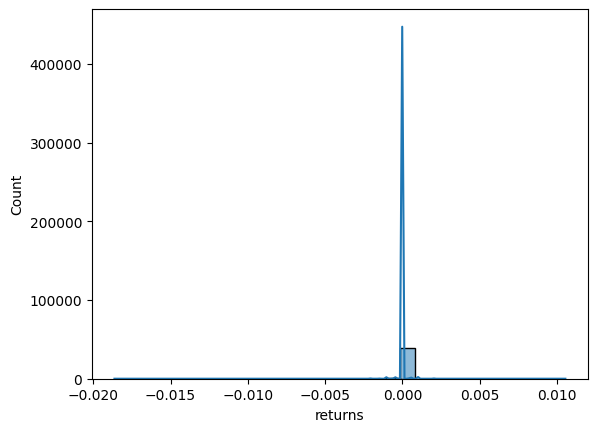

In [13]:
arith_return = market_data.get_returns()
sns.histplot(arith_return, bins=30, kde=True)

<Axes: xlabel='log_returns', ylabel='Count'>

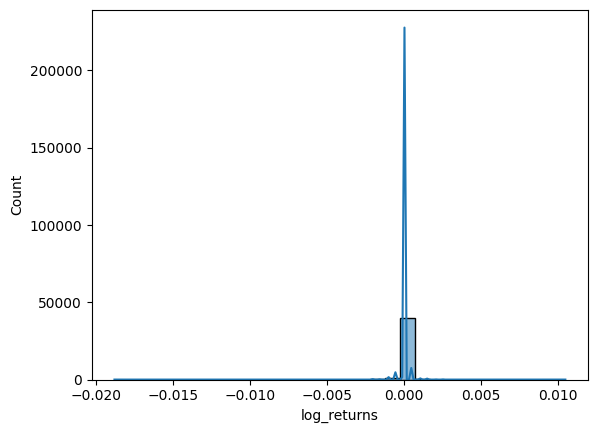

In [12]:
log_returns = market_data.get_log_returns()
sns.histplot(log_returns, bins=30, kde=True)

In [13]:
# Perform Mean Reversal
rule = MeanReversal(lookback_window=5, entry_z_threshold_entry=1.0, exit_z_threshold=0.5)
positions = perform_mean_reversal_backtest(rule, market_data, positions)
positions_df = positions.get_returns_from_trade_history()

In [14]:
positions.get_cumulative_annualized_returns()

0.0017136363548182487

In [15]:
positions.calculate_annualized_sharpe_ratio()

5.77485280234341